# Shailesh Gowtham V - 24BAD108

In [ ]:
# Numerical & Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

# Display first few rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Dataset info
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [ ]:
# No missing values in dataset, so skip imputation

# Select relevant features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

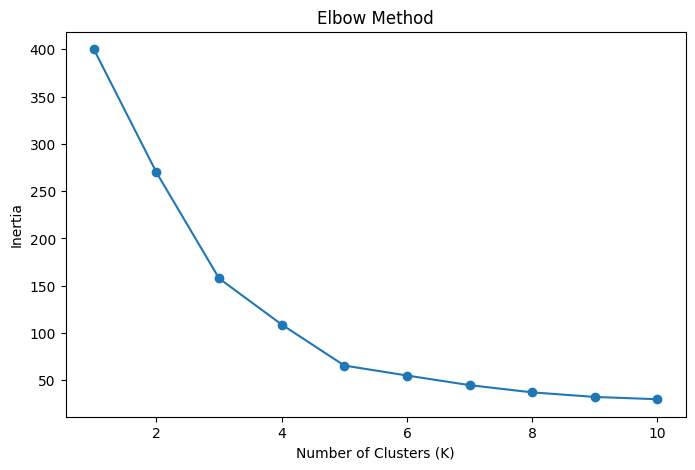

In [ ]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
# Choose optimal K (example: 5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit model
clusters = kmeans.fit_predict(X_scaled)

# Assign cluster labels
df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
# Inertia
print("Inertia:", kmeans.inertia_)

# Silhouette Score
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


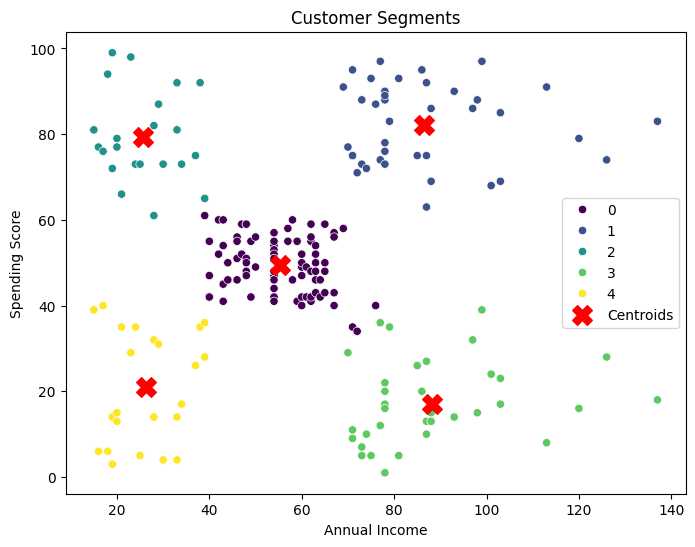

In [ ]:
# Scatter plot of clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

# Plot centroids (convert back to original scale)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=200,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [ ]:
# Group by cluster and find mean values
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [ ]:
for i in range(5):
    print(f"\nCluster {i}:")
    print(cluster_summary.loc[i])


Cluster 0:
Annual Income (k$)        55.296296
Spending Score (1-100)    49.518519
Name: 0, dtype: float64

Cluster 1:
Annual Income (k$)        86.538462
Spending Score (1-100)    82.128205
Name: 1, dtype: float64

Cluster 2:
Annual Income (k$)        25.727273
Spending Score (1-100)    79.363636
Name: 2, dtype: float64

Cluster 3:
Annual Income (k$)        88.200000
Spending Score (1-100)    17.114286
Name: 3, dtype: float64

Cluster 4:
Annual Income (k$)        26.304348
Spending Score (1-100)    20.913043
Name: 4, dtype: float64


In [ ]:
# Test different initializations
kmeans_random = KMeans(n_clusters=5, init='random', random_state=42)
kmeans_kpp = KMeans(n_clusters=5, init='k-means++', random_state=42)

kmeans_random.fit(X_scaled)
kmeans_kpp.fit(X_scaled)

print("Random Init Inertia:", kmeans_random.inertia_)
print("KMeans++ Init Inertia:", kmeans_kpp.inertia_)

Random Init Inertia: 65.56840815571681
KMeans++ Init Inertia: 65.56840815571681


# Scenario - 2

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# For comparison
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [ ]:
# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

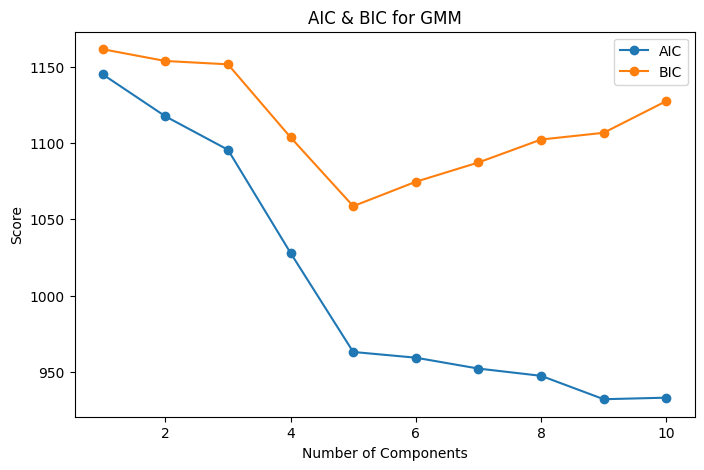

In [ ]:
aic = []
bic = []

K_range = range(1, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

# Plot AIC & BIC
plt.figure(figsize=(8,5))
plt.plot(K_range, aic, label='AIC', marker='o')
plt.plot(K_range, bic, label='BIC', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.title('AIC & BIC for GMM')
plt.legend()
plt.show()

In [ ]:
# Choose optimal components (example: 5)
gmm = GaussianMixture(n_components=5, random_state=42)

# Fit model (EM algorithm)
gmm.fit(X_scaled)

GaussianMixture(n_components=5, random_state=42)

In [ ]:
# Soft clustering (probabilities)
probs = gmm.predict_proba(X_scaled)

# Show first few probability distributions
pd.DataFrame(probs).head()

,0,1,2,3,4
0,1.576897e-05,1.880092e-08,9.520312e-04,5.200131e-08,0.999032
1,1.627762e-05,1.895968e-04,9.997902e-01,4.210134e-23,0.000004
2,2.213394e-19,9.526157e-19,1.225495e-12,1.862233e-04,0.999814
3,1.054448e-04,1.800877e-04,9.996937e-01,3.793901e-21,0.000021
4,6.473014e-05,3.842732e-08,1.556695e-03,4.757227e-08,0.998378


In [ ]:
# Hard clustering
labels = gmm.predict(X_scaled)

df['GMM_Cluster'] = labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),GMM_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
# Log Likelihood
log_likelihood = gmm.score(X_scaled)
print("Log-Likelihood:", log_likelihood)

# AIC & BIC
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

# Silhouette Score
sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


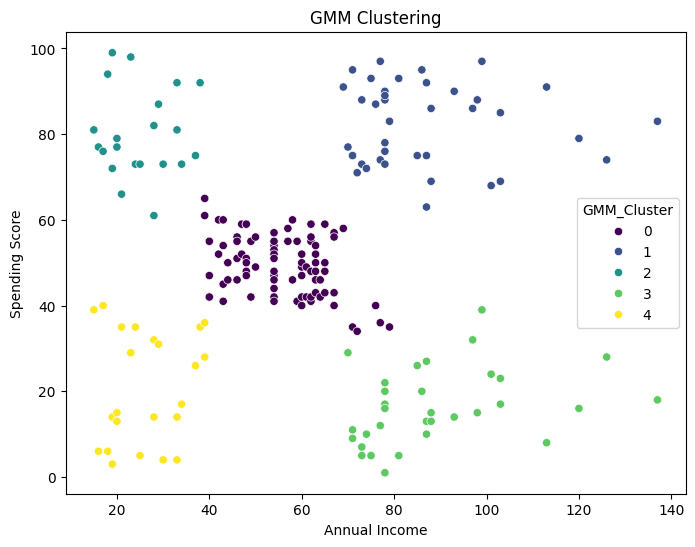

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['GMM_Cluster'],
    palette='viridis'
)

plt.title('GMM Clustering')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

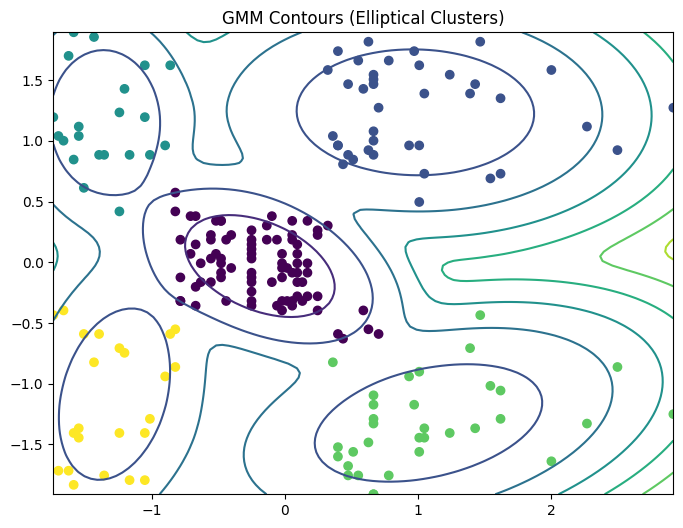

In [ ]:
# Create grid for contour
x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)

XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T
Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)

plt.figure(figsize=(8,6))
plt.contour(X_grid, Y_grid, Z)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis')
plt.title('GMM Contours (Elliptical Clusters)')
plt.show()

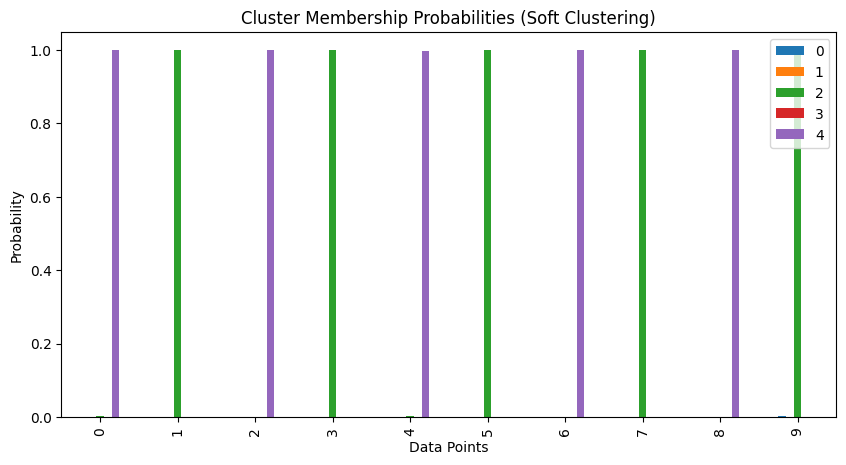

In [ ]:
# Plot probability distribution for first 10 samples
pd.DataFrame(probs[:10]).plot(kind='bar', figsize=(10,5))
plt.title('Cluster Membership Probabilities (Soft Clustering)')
plt.xlabel('Data Points')
plt.ylabel('Probability')
plt.show()

In [ ]:
# K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

In [ ]:
plt.figure(figsize=(12,5))

# K-Means
plt.subplot(1,2,1)
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['KMeans_Cluster'],
    palette='viridis'
)
plt.title('K-Means Clustering')

# GMM
plt.subplot(1,2,2)
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['GMM_Cluster'],
    palette='viridis'
)
plt.title('GMM Clustering')

plt.show()